## LING 498 Hackathon - Phoneme token frequencies (CMUdict)

**Question: Do ARPAbet phoneme tokens show Zipf-like rank-frequency patterns?**

In [1]:
import re
from nltk.corpus import cmudict
from nltk import FreqDist

# If CMUdict isn't already downloaded in runtime, uncomment:
# nltk.download("cmudict")

In [2]:
# Function to print a quick Zipf-style report of item frequencies
def zipf_quick_report(items, title="", topn=15, min_count=1):
    fd = FreqDist(items)
    ranked = sorted(((k,v) for k,v in fd.items() if v >= min_count),
                    key=lambda kv: kv[1], reverse=True)
    print(f"\n=== {title} ===")
    print(f"Types: {len(ranked)} | Tokens: {sum(v for _,v in ranked)}")
    for i,(k,v) in enumerate(ranked[:topn], start=1):
        print(f"{i:>2}. {k:<8} {v}")
    return ranked

In [3]:
# Zipf-style graph
def zipf_plot_simple(ranked, n=30, title="Phoneme frequency by rank"):
    import matplotlib.pyplot as plt
    ranks = list(range(1, min(n, len(ranked)) + 1))
    freqs = [ranked[i-1][1] for i in ranks]
    plt.figure(figsize=(8,5))
    plt.plot(ranks, freqs, marker="o")
    plt.xlabel("Rank (1 = most common phoneme)")
    plt.ylabel("Frequency (token count)")
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [4]:
# Load CMUdict entries: (word, pronunciation_list)
entries = cmudict.entries()
print("Number of entries:", len(entries))

Number of entries: 133737


In [5]:
# Remove stress digits from phones (AH0 -> AH)
def normalize_phone(phone: str) -> str:
    return re.sub(r"\d", "", phone)

In [6]:
# List of phoneme tokens across the lexicon
phones = []
for word, pron in entries:
    phones.extend(normalize_phone(p) for p in pron)


=== CMUdict phoneme token frequencies (stress stripped) ===
Types: 39 | Tokens: 853918
 1. AH       71410
 2. N        60564
 3. S        50427
 4. IH       50093
 5. L        49479
 6. T        48549
 7. R        46046
 8. K        42502
 9. IY       34504
10. D        32389
11. M        29347
12. ER       29027
13. Z        27842
14. EH       27398
15. AA       24546


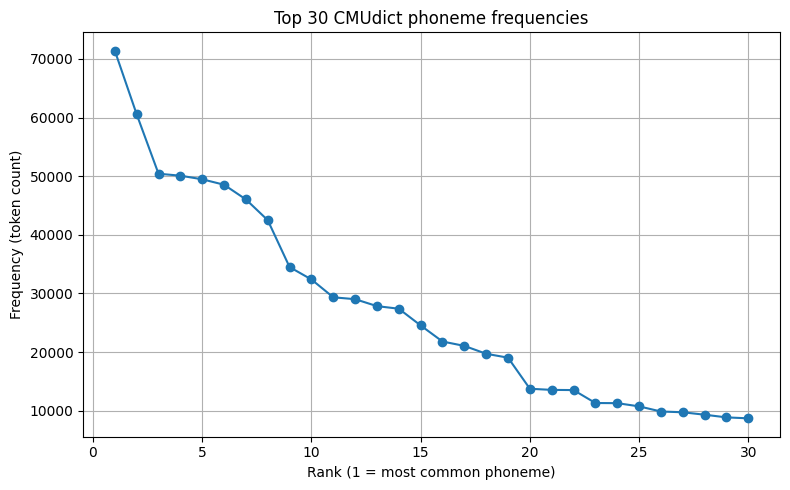

In [7]:
# Count + rank + print Zipf-style report
ranked = zipf_quick_report(
    phones,
    title="CMUdict phoneme token frequencies (stress stripped)",
    topn=15
)

zipf_plot_simple(
    ranked,
    n=30,
    title="Top 30 CMUdict phoneme frequencies"
)